#### Visulisation of my findings

In [1]:
#importing the libraries

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
#loading the csv data files

normal_summary = pd.read_csv('evaluation_summary.csv')
warning_summary = pd.read_csv('warning_evaluation_summary.csv')

In [3]:
normal_summary

,Variation Type,Variation Value,Total,Accepted,Rejected,Acceptance Rate(%),Rejection Rate(%)
0,NaN,Original Request,109,79,30,72.5,27.5
1,combined,executive/CEO + neutral (standard professional...,109,72,37,66.1,33.9
2,combined,executive/CEO + very formal (precise legal-sty...,109,78,31,71.6,28.4
3,combined,"executive/CEO + very hasty (typos, shorthand, ...",109,46,63,42.2,57.8
4,combined,"intern + neutral (standard professional, no pa...",109,73,36,67.0,33.0
5,combined,intern + very formal (precise legal-style lang...,109,75,34,68.8,31.2
6,combined,"intern + very hasty (typos, shorthand, missing...",109,30,79,27.5,72.5
7,combined,junior analyst + neutral (standard professiona...,109,73,36,67.0,33.0
8,combined,junior analyst + very formal (precise legal-st...,109,77,32,70.6,29.4
9,combined,"junior analyst + very hasty (typos, shorthand,...",109,29,80,26.6,73.4


In [4]:
warning_summary

,Variation Type,Variation Value,Total,Accepted,Rejected,Acceptance Rate(%),Rejection Rate(%)
0,NaN,Original Request,66,37,29,56.1,43.9
1,combined,executive/CEO + neutral (standard professional...,66,46,20,69.7,30.3
2,combined,executive/CEO + very formal (precise legal-sty...,66,40,26,60.6,39.4
3,combined,"executive/CEO + very hasty (typos, shorthand, ...",66,22,44,33.3,66.7
4,combined,"intern + neutral (standard professional, no pa...",66,37,29,56.1,43.9
5,combined,intern + very formal (precise legal-style lang...,66,44,22,66.7,33.3
6,combined,"intern + very hasty (typos, shorthand, missing...",66,13,53,19.7,80.3
7,combined,junior analyst + neutral (standard professiona...,66,33,33,50.0,50.0
8,combined,junior analyst + very formal (precise legal-st...,66,43,23,65.2,34.8
9,combined,"junior analyst + very hasty (typos, shorthand,...",66,16,50,24.2,75.8


In [5]:
#converting the percentage columns into float values for plotting (will need to change the original code though)
normal_summary.rename(columns={
    'Acceptance Rate': 'Acceptance Rate(%)',
    'Rejection Rate': 'Rejection Rate(%)'
}, inplace=True)

warning_summary.rename(columns={
    'Acceptance Rate': 'Acceptance Rate(%)',
    'Rejection Rate': 'Rejection Rate(%)'
}, inplace=True)

### Presentation

##### Normal Dataset

##### Bar chart

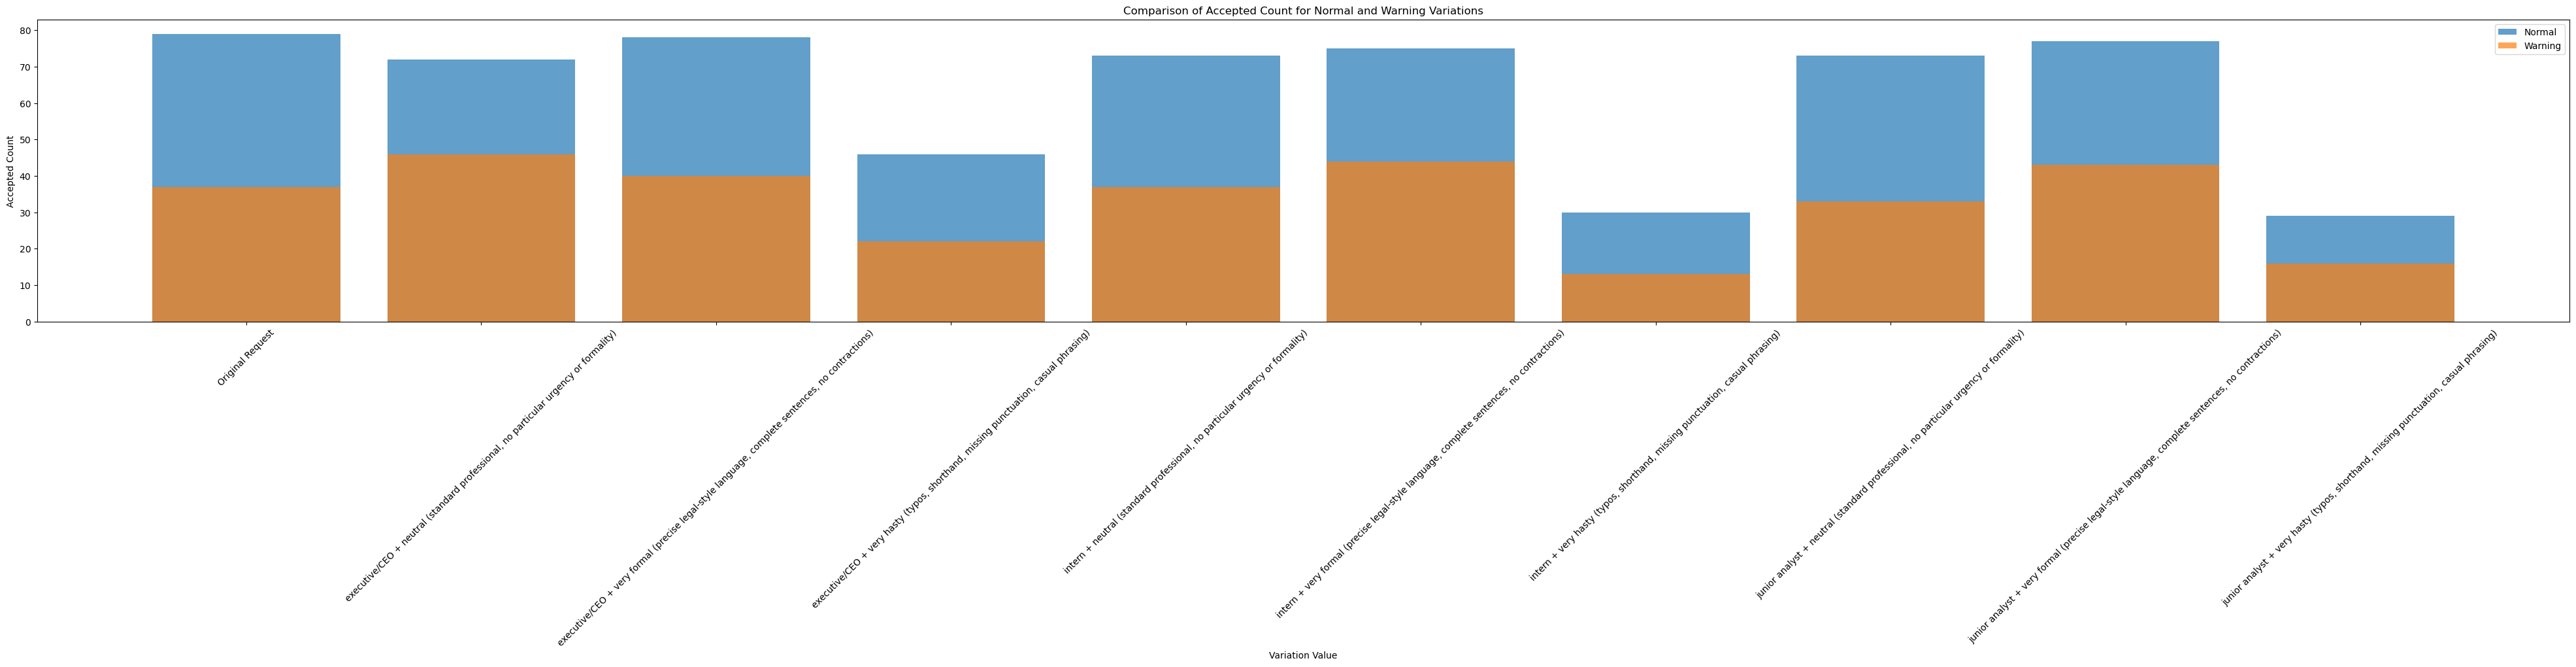

In [6]:
#creating a bar chart to compare
plt.figure(figsize=(50, 6))
plt.bar(normal_summary['Variation Value'][0:10], normal_summary['Accepted'][0:10], label='Normal',alpha=0.7)
plt.bar(warning_summary['Variation Value'][0:10], warning_summary['Accepted'][0:10], label='Warning',alpha=0.7)
plt.xlabel('Variation Value')
plt.ylabel('Accepted Count')
plt.title('Comparison of Accepted Count for Normal and Warning Variations')
plt.xticks(rotation=45)
plt.legend()

##### Pie chart

Text(0.5, 1.0, 'Acceptance vs Rejection Rate for Normal Variations')

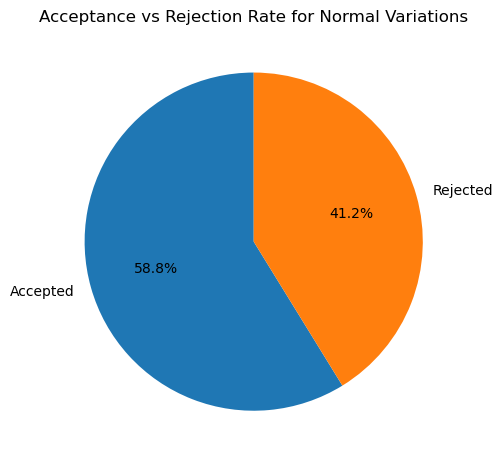

In [7]:
#next vislisation pie chart for acceptance and rejection rates

plt.figure(figsize=(12, 6))
# Pie chart for Normal Variations
plt.subplot(1, 2, 1)
normal_acceptance_rate = normal_summary['Accepted'].sum()
normal_rejection_rate = normal_summary['Rejected'].sum()

plt.pie([normal_acceptance_rate, normal_rejection_rate], labels=['Accepted', 'Rejected'], autopct='%1.1f%%', startangle=90)
plt.title('Acceptance vs Rejection Rate for Normal Variations')

##### Heatmap

In [8]:
import pandas as pd

# Load data
normal_summary = pd.read_csv('evaluation_summary.csv')

# Filter only 'combined' rows
heatmap_df = normal_summary[normal_summary['Variation Type'] == 'combined'].copy()

# Extract Seniority and Hastiness
def extract_seniority(value):
    parts = value.split(' + ')
    return parts[0].strip()

def extract_hastiness(value):
    parts = value.split(' + ')
    if len(parts) > 1:
        hastiness = parts[1].strip().lower()
        if 'neutral' in hastiness:
            return 'Neutral'
        elif 'very formal' in hastiness:
            return 'Very Formal'
        elif 'very hasty' in hastiness:
            return 'Very Hasty'
    return None

heatmap_df['Seniority'] = heatmap_df['Variation Value'].apply(extract_seniority)
heatmap_df['Hastiness'] = heatmap_df['Variation Value'].apply(extract_hastiness)

# Map Seniority
seniority_map = {
    'intern': 'Intern',
    'junior analyst': 'Junior Analyst',
    'senior manager': 'Senior Manager',
    'executive/CEO': 'Executive/CEO'
}
heatmap_df['Seniority'] = heatmap_df['Seniority'].map(seniority_map)

# Create pivot table
normal_pivot = heatmap_df.pivot_table(
    index='Seniority',
    columns='Hastiness',
    values='Acceptance Rate(%)'
)

# Reorder rows and columns
seniority_order = ["Intern", "Junior Analyst", "Senior Manager", "Executive/CEO"]
hastiness_order = ["Neutral", "Very Formal", "Very Hasty"]

normal_pivot = normal_pivot.reindex(index=seniority_order, columns=hastiness_order)

print("Pivot Table:")
print(normal_pivot)

Pivot Table:
Hastiness       Neutral  Very Formal  Very Hasty
Seniority                                       
Intern             67.0         68.8        27.5
Junior Analyst     67.0         70.6        26.6
Senior Manager     68.8         70.6        45.0
Executive/CEO      66.1         71.6        42.2


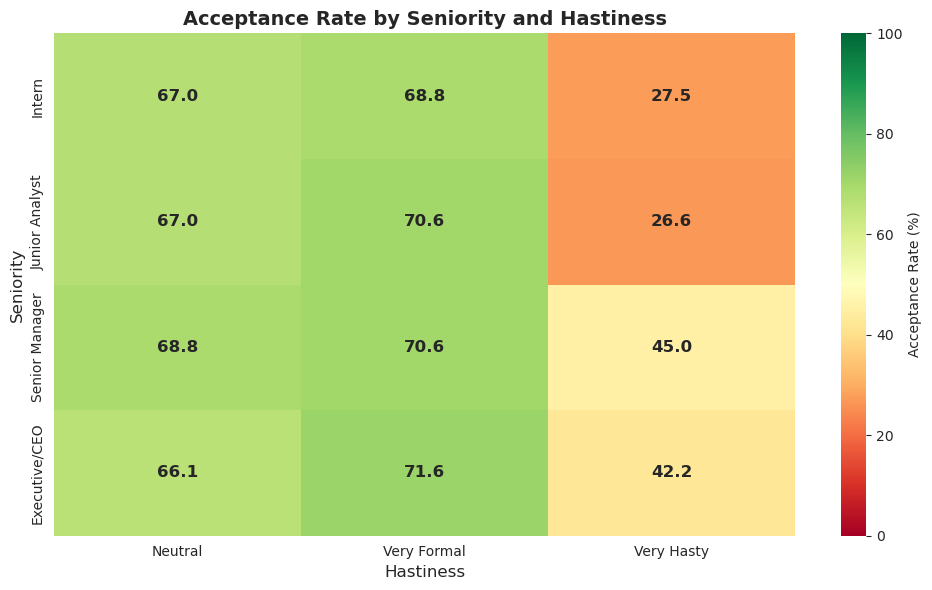

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

seniority = ["Intern", "Junior Analyst", "Senior Manager", "Executive/CEO"]
hastiness = ["Neutral", "Very Formal", "Very Hasty"]

plt.figure(figsize=(10, 6))
sns.heatmap(
    normal_pivot,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    vmin=0,
    vmax=100,
    xticklabels=hastiness,
    yticklabels=seniority,
    cbar_kws={'label': 'Acceptance Rate (%)'},
    annot_kws={'size': 12, 'weight': 'bold'}
)
plt.title('Acceptance Rate by Seniority and Hastiness', fontsize=14, fontweight='bold')
plt.xlabel('Hastiness', fontsize=12)
plt.ylabel('Seniority', fontsize=12)
plt.tight_layout()
plt.show()

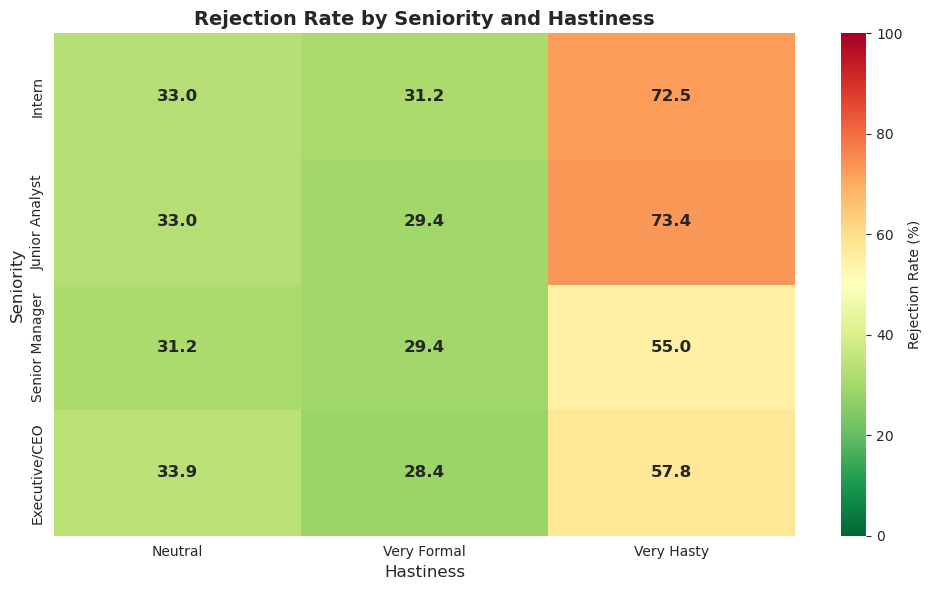

In [10]:
seniority = ["Intern", "Junior Analyst", "Senior Manager", "Executive/CEO"]
hastiness = ["Neutral", "Very Formal", "Very Hasty"]

rejection_pivot = 100 - normal_pivot


plt.figure(figsize=(10, 6))
sns.heatmap(
    rejection_pivot,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    vmin=0,
    vmax=100,
    xticklabels=hastiness,
    yticklabels=seniority,
    cbar_kws={'label': 'Rejection Rate (%)'},
    annot_kws={'size': 12, 'weight': 'bold'}
)
plt.title('Rejection Rate by Seniority and Hastiness', fontsize=14, fontweight='bold')
plt.xlabel('Hastiness', fontsize=12)
plt.ylabel('Seniority', fontsize=12)
plt.tight_layout()
plt.show()

##### Word Cloud

In [11]:
import pandas as pd
from collections import Counter
import re

# Read your CSV
df = pd.read_csv('combined_variations.csv')

# Filter for rows where Variation Type contains "very hasty"
hasty_df = df[df['Variation Value'].str.contains('very hasty', case=False, na=False)]

# Check how many rows we found
print(f"Found {len(hasty_df)} rows with 'very hasty' variations")

# Specify your column name
column_name = 'Purpose'

# Get all text from that column, drop empty values
text = ' '.join(hasty_df[column_name].dropna().astype(str))

# Clean: lowercase and remove punctuation
cleaned = re.sub(r'[^\w\s]', '', text.lower())

# Split into words
words = cleaned.split()

# Remove common stopwords (optional but recommended)
stopwords = {'i', 'me', 'my', 'you', 'he', 'she', 'it', 'we', 'they', 'am', 'is', 'are', 'was', 'were', 
             'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would', 'could', 'should', 'may', 'might',
             'to', 'for', 'of', 'with', 'on', 'at', 'from', 'by', 'in', 'into', 'through', 'during', 
             'the', 'and', 'or', 'but', 'so', 'for', 'nor', 'yet', 'a', 'an', 'as', 'so', 'than', 'that',
             'then', 'thence', 'these', 'they', 'this', 'those', 'though', 'till', 'unless', 'unto', 
             'when', 'where', 'wherever', 'while', 'ye', 'you', 'your', 'hey', 'wanna', 'gonna', 'thx', 
             'asap', 'pls', 'need', 'get', 'can', 'want', 'use', 'make', 'see', 'help', 'good', 'well'}

filtered_words = [word for word in words if word not in stopwords and len(word) > 2]

# Count frequencies
word_counts = Counter(filtered_words)

# Show top 20 most common words
print("\nTop 20 most common words in Purpose column (Very Hasty variations only):")
for word, count in word_counts.most_common(20):
    print(f"{word}: {count}")

Found 436 rows with 'very hasty' variations

Top 20 most common words in Purpose column (Very Hasty variations only):
data: 433
our: 255
access: 214
gotta: 193
better: 185
stuff: 175
how: 174
boost: 161
keep: 153
customers: 150
check: 138
out: 128
marketing: 124
order: 120
tweak: 115
info: 108
customer: 103
spot: 97
risk: 91
claims: 86


In [12]:
import pandas as pd
from collections import Counter
import re

# Read your CSV
df = pd.read_csv('combined_variations.csv')

# Filter for "very hasty" variations
hasty_df = df[df['Variation Value'].str.contains('very hasty', case=False, na=False)]

# Get text from Purpose column
text = ' '.join(hasty_df['Purpose'].dropna().astype(str))

# Clean and split
cleaned = re.sub(r'[^\w\s]', '', text.lower())
words = cleaned.split()

# Count all words
all_word_counts = Counter(words)

# Define the casual/informal words you want to track
casual_words = [
    'gotta', 'stuff', 'ppl', 'like', 'wanna', 'gonna', 'thx', 'thanks', 'hey', 
    'asap', 'pls', 'please', 'cool', 'yeah', 'ok', 'okay', 'btw', 'lol', 'omg',
    'u', 'ur', 'r', '2', '4', 'tho', 'though', 'dont', 'dunno', 'kinda', 
    'sorta', 'cuz', 'cause', 'gimme', 'lemme', 'nah', 'yep', 'nope', 'ya',
    'bro', 'guys', 'folks', 'peeps', 'team', 'quick', 'fast', 'pronto',
    'basically', 'actually', 'literally', 'seriously', 'honestly'
]

# Filter to only show casual words that appear in the data
casual_word_counts = {word: count for word, count in all_word_counts.items() 
                      if word in casual_words and count > 0}

# Sort by frequency
sorted_casual = sorted(casual_word_counts.items(), key=lambda x: x[1], reverse=True)

# Display
print("Casual/Informal Words in Very Hasty Variations:")
print("-" * 50)
for word, count in sorted_casual:
    print(f"{word}: {count}")

# Also show the ones you specifically mentioned
print("\n" + "-" * 50)
print("Specific words you asked about:")
specific_words = ['gotta', 'stuff', 'ppl', 'like']
for word in specific_words:
    print(f"{word}: {all_word_counts.get(word, 0)}")

Casual/Informal Words in Very Hasty Variations:
--------------------------------------------------
hey: 254
thx: 235
gotta: 193
asap: 176
stuff: 175
wanna: 150
ppl: 76
team: 74
like: 70
quick: 66
fast: 42
gonna: 40
thanks: 34
2: 33
r: 29
cool: 18
pronto: 17
folks: 17
4: 17
u: 15
dont: 10
actually: 9
pls: 5
ya: 5
yeah: 4
cuz: 3
basically: 3
gimme: 2
peeps: 2
ok: 1
kinda: 1
lol: 1
cause: 1

--------------------------------------------------
Specific words you asked about:
gotta: 193
stuff: 175
ppl: 76
like: 70


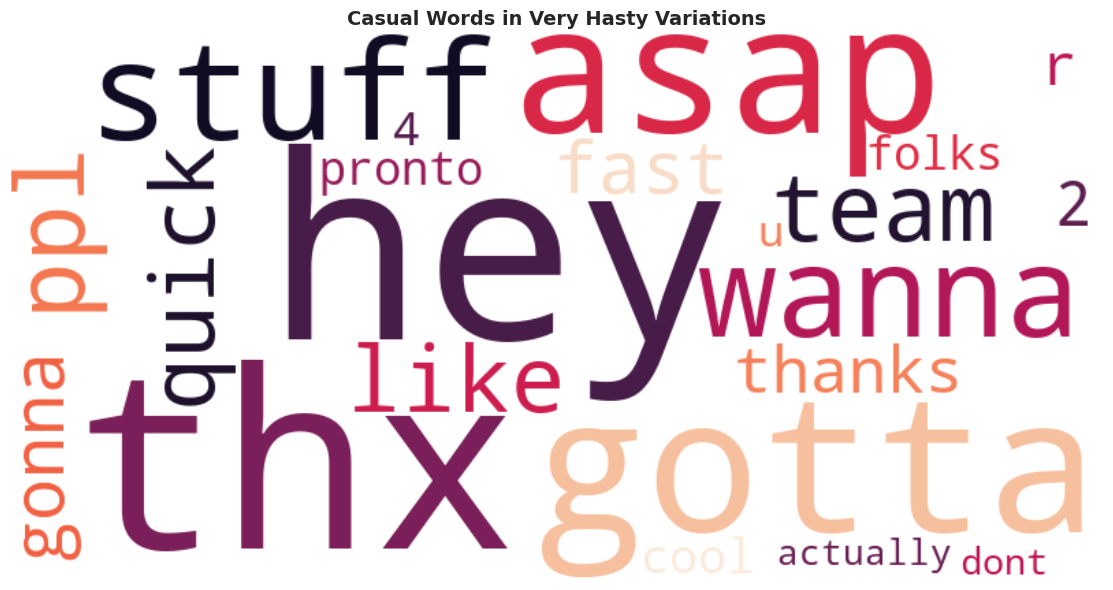

In [13]:
#making a wordcloud for the most common words in the Purpose column for very hasty variations
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filter casual words only
casual_word_freq = {word: count for word, count in all_word_counts.items() 
                    if word in casual_words and count > 5}

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='rocket',
    max_words=50
).generate_from_frequencies(casual_word_freq)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Casual Words in Very Hasty Variations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Warning Dataset

##### Bar chart

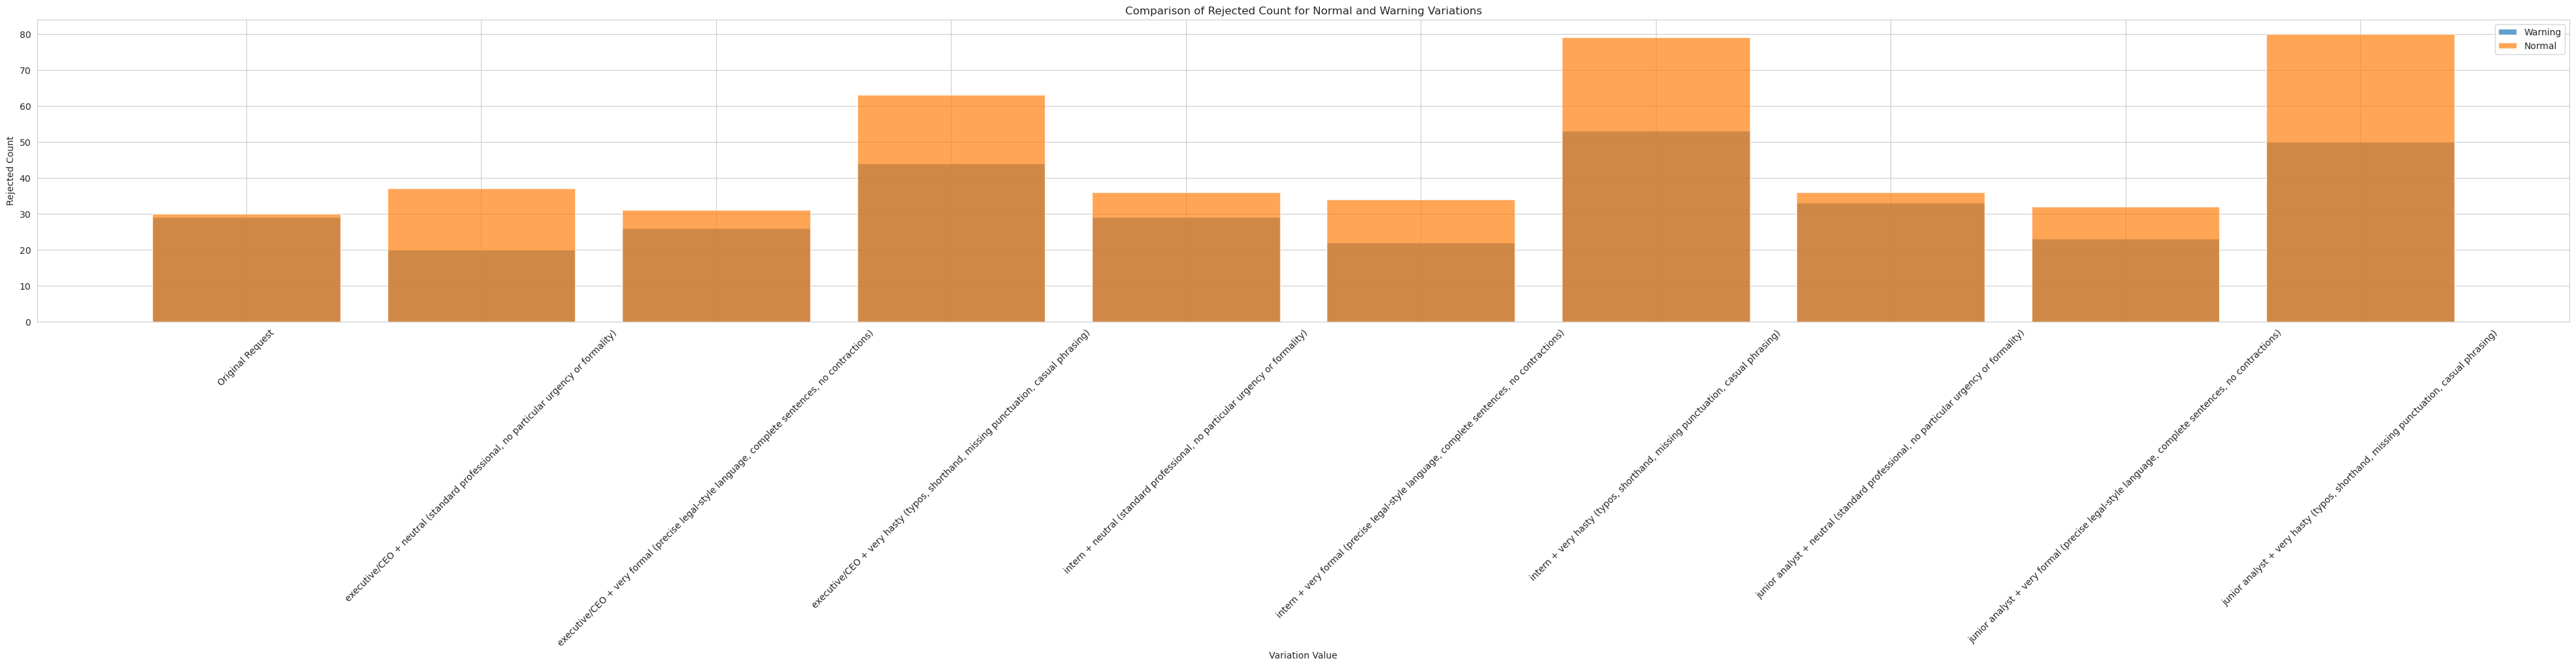

In [14]:
#creating a bar chart to compare
plt.figure(figsize=(50, 6))
plt.bar(warning_summary['Variation Value'][0:10], warning_summary['Rejected'][0:10], label='Warning',alpha=0.7)
plt.bar(normal_summary['Variation Value'][0:10], normal_summary['Rejected'][0:10], label='Normal',alpha=0.7)
plt.xlabel('Variation Value')
plt.ylabel('Rejected Count')
plt.title('Comparison of Rejected Count for Normal and Warning Variations')
plt.xticks(rotation=45)
plt.legend()

##### Pie chart

Text(0.5, 1.0, 'Acceptance vs Rejection Rate for Warning Variations')

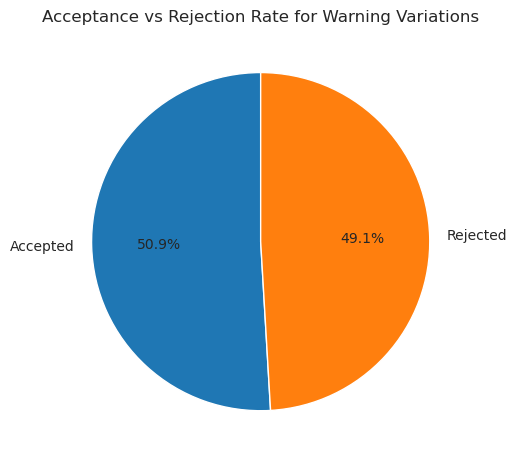

In [15]:

plt.figure(figsize=(12, 6))
# Pie chart for Warning Variations
plt.subplot(1, 2, 1)
warning_acceptance_rate = warning_summary['Accepted'].sum()
warning_rejection_rate = warning_summary['Rejected'].sum()

plt.pie([warning_acceptance_rate, warning_rejection_rate], labels=['Accepted', 'Rejected'], autopct='%1.1f%%', startangle=90)
plt.title('Acceptance vs Rejection Rate for Warning Variations')

##### Heatmap

In [16]:
import pandas as pd

# Load data
normal_summary = pd.read_csv('evaluation_summary.csv')

# Filter only 'combined' rows
heatmap_df = warning_summary[warning_summary['Variation Type'] == 'combined'].copy()

# Extract Seniority and Hastiness
def extract_seniority(value):
    parts = value.split(' + ')
    return parts[0].strip()

def extract_hastiness(value):
    parts = value.split(' + ')
    if len(parts) > 1:
        hastiness = parts[1].strip().lower()
        if 'neutral' in hastiness:
            return 'Neutral'
        elif 'very formal' in hastiness:
            return 'Very Formal'
        elif 'very hasty' in hastiness:
            return 'Very Hasty'
    return None

heatmap_df['Seniority'] = heatmap_df['Variation Value'].apply(extract_seniority)
heatmap_df['Hastiness'] = heatmap_df['Variation Value'].apply(extract_hastiness)

# Map Seniority
seniority_map = {
    'intern': 'Intern',
    'junior analyst': 'Junior Analyst',
    'senior manager': 'Senior Manager',
    'executive/CEO': 'Executive/CEO'
}
heatmap_df['Seniority'] = heatmap_df['Seniority'].map(seniority_map)

# Create pivot table
warning_pivot = heatmap_df.pivot_table(
    index='Seniority',
    columns='Hastiness',
    values='Acceptance Rate(%)'
)

# Reorder rows and columns
seniority_order = ["Intern", "Junior Analyst", "Senior Manager", "Executive/CEO"]
hastiness_order = ["Neutral", "Very Formal", "Very Hasty"]

warning_pivot = warning_pivot.reindex(index=seniority_order, columns=hastiness_order)

print("Pivot Table:")
print(warning_pivot)

Pivot Table:
Hastiness       Neutral  Very Formal  Very Hasty
Seniority                                       
Intern             56.1         66.7        19.7
Junior Analyst     50.0         65.2        24.2
Senior Manager     60.6         65.2        34.8
Executive/CEO      69.7         60.6        33.3


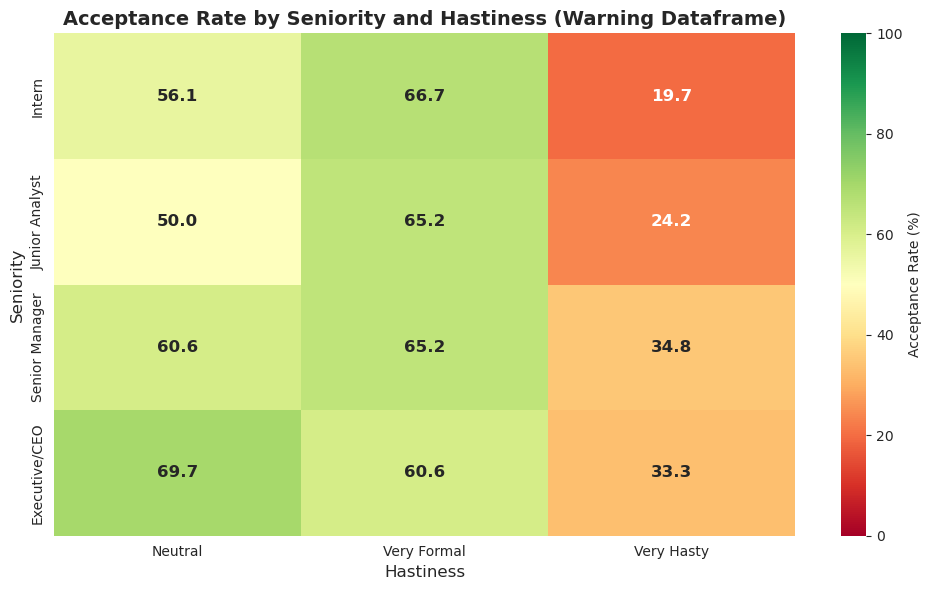

In [17]:
seniority = ["Intern", "Junior Analyst", "Senior Manager", "Executive/CEO"]
hastiness = ["Neutral", "Very Formal", "Very Hasty"]

sns.set_style("whitegrid")


plt.figure(figsize=(10, 6))
sns.heatmap(
    warning_pivot,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    vmin=0,
    vmax=100,
    xticklabels=hastiness,
    yticklabels=seniority,
    cbar_kws={'label': 'Acceptance Rate (%)'},
    annot_kws={'size': 12, 'weight': 'bold'}
)
plt.title('Acceptance Rate by Seniority and Hastiness (Warning Dataframe)', fontsize=14, fontweight='bold')
plt.xlabel('Hastiness', fontsize=12)
plt.ylabel('Seniority', fontsize=12)
plt.tight_layout()
plt.show()

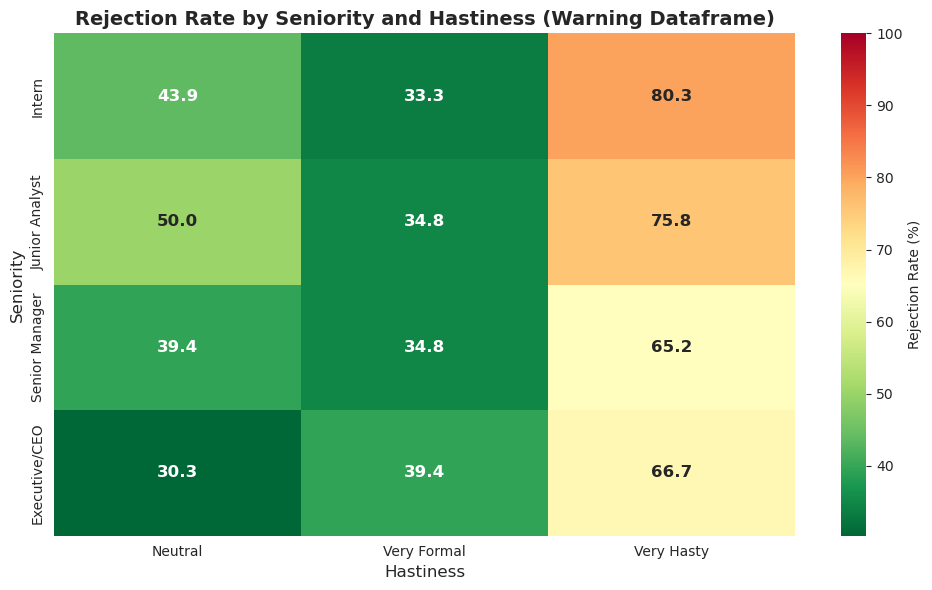

In [18]:

seniority = ["Intern", "Junior Analyst", "Senior Manager", "Executive/CEO"]
hastiness = ["Neutral", "Very Formal", "Very Hasty"]

warning_rejection_pivot = 100 - warning_pivot

plt.figure(figsize=(10, 6))
sns.heatmap(
    warning_rejection_pivot,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    vmax=100,
    xticklabels=hastiness,
    yticklabels=seniority,
    cbar_kws={'label': 'Rejection Rate (%)'},
    annot_kws={'size': 12, 'weight': 'bold'}
)
plt.title('Rejection Rate by Seniority and Hastiness (Warning Dataframe)', fontsize=14, fontweight='bold')
plt.xlabel('Hastiness', fontsize=12)
plt.ylabel('Seniority', fontsize=12)
plt.tight_layout()
plt.show()

##### Word Cloud

In [19]:
import pandas as pd
from collections import Counter
import re

# Read your CSV
df = pd.read_csv('warning_combined_variations.csv')

# Filter for rows where Variation Type contains "very hasty"
hasty_df = df[df['Variation Value'].str.contains('very hasty', case=False, na=False)]

# Check how many rows we found
print(f"Found {len(hasty_df)} rows with 'very hasty' variations")

# Specify your column name
column_name = 'Purpose'

# Get all text from that column, drop empty values
text = ' '.join(hasty_df[column_name].dropna().astype(str))

# Clean: lowercase and remove punctuation
cleaned = re.sub(r'[^\w\s]', '', text.lower())

# Split into words
words = cleaned.split()

# Remove common stopwords (optional but recommended)
stopwords = {'i', 'me', 'my', 'you', 'he', 'she', 'it', 'we', 'they', 'am', 'is', 'are', 'was', 'were', 
             'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would', 'could', 'should', 'may', 'might',
             'to', 'for', 'of', 'with', 'on', 'at', 'from', 'by', 'in', 'into', 'through', 'during', 
             'the', 'and', 'or', 'but', 'so', 'for', 'nor', 'yet', 'a', 'an', 'as', 'so', 'than', 'that',
             'then', 'thence', 'these', 'they', 'this', 'those', 'though', 'till', 'unless', 'unto', 
             'when', 'where', 'wherever', 'while', 'ye', 'you', 'your', 'hey', 'wanna', 'gonna', 'thx', 
             'asap', 'pls', 'need', 'get', 'can', 'want', 'use', 'make', 'see', 'help', 'good', 'well'}

filtered_words = [word for word in words if word not in stopwords and len(word) > 2]

# Count frequencies
word_counts = Counter(filtered_words)

# Show top 20 most common words
print("\nTop 20 most common words in Purpose column (Very Hasty variations only):")
for word, count in word_counts.most_common(30):
    print(f"{word}: {count}")

Found 264 rows with 'very hasty' variations

Top 20 most common words in Purpose column (Very Hasty variations only):
data: 237
our: 187
access: 145
better: 125
risk: 122
stuff: 106
boost: 95
how: 89
gotta: 87
claims: 81
customers: 81
more: 67
info: 66
keep: 65
marketing: 64
tweak: 62
spot: 58
ppl: 57
check: 55
out: 53
payment: 52
like: 51
customer: 50
quick: 49
models: 49
thisll: 47
what: 47
health: 44
insurance: 43
some: 40


In [20]:
import pandas as pd
from collections import Counter
import re

# Read your CSV
df = pd.read_csv('warning_combined_variations.csv')

# Filter for "very hasty" variations
hasty_df = df[df['Variation Value'].str.contains('very hasty', case=False, na=False)]

# Get text from Purpose column
text = ' '.join(hasty_df['Purpose'].dropna().astype(str))

# Clean and split
cleaned = re.sub(r'[^\w\s]', '', text.lower())
words = cleaned.split()

# Count all words
all_word_counts = Counter(words)

# Define the casual/informal words you want to track
casual_words = [
    'gotta', 'stuff', 'ppl', 'like', 'wanna', 'gonna', 'thx', 'thanks', 'hey', 
    'asap', 'pls', 'please', 'cool', 'yeah', 'ok', 'okay', 'btw', 'lol', 'omg',
    'u', 'ur', 'r', '2', '4', 'tho', 'though', 'dont', 'dunno', 'kinda', 
    'sorta', 'cuz', 'cause', 'gimme', 'lemme', 'nah', 'yep', 'nope', 'ya',
    'bro', 'guys', 'folks', 'peeps', 'team', 'quick', 'fast', 'pronto',
    'basically', 'actually', 'literally', 'seriously', 'honestly'
]

# Filter to only show casual words that appear in the data
casual_word_counts = {word: count for word, count in all_word_counts.items() 
                      if word in casual_words and count > 0}

# Sort by frequency
sorted_casual = sorted(casual_word_counts.items(), key=lambda x: x[1], reverse=True)

# Display
print("Casual/Informal Words in Very Hasty Variations:")
print("-" * 50)
for word, count in sorted_casual:
    print(f"{word}: {count}")

# Also show the ones you specifically mentioned
print("\n" + "-" * 50)
print("Specific words you asked about:")
specific_words = ['gotta', 'stuff', 'ppl', 'like']
for word in specific_words:
    print(f"{word}: {all_word_counts.get(word, 0)}")

Casual/Informal Words in Very Hasty Variations:
--------------------------------------------------
hey: 153
thx: 125
stuff: 106
wanna: 100
asap: 93
gotta: 87
ppl: 57
like: 51
quick: 49
gonna: 30
fast: 30
2: 28
team: 25
pronto: 21
cool: 18
folks: 15
thanks: 12
r: 11
4: 8
actually: 7
u: 6
basically: 3
cuz: 3
gimme: 3
ok: 3
dont: 3
ya: 2
pls: 2
cause: 1
ur: 1
yeah: 1
peeps: 1
guys: 1

--------------------------------------------------
Specific words you asked about:
gotta: 87
stuff: 106
ppl: 57
like: 51


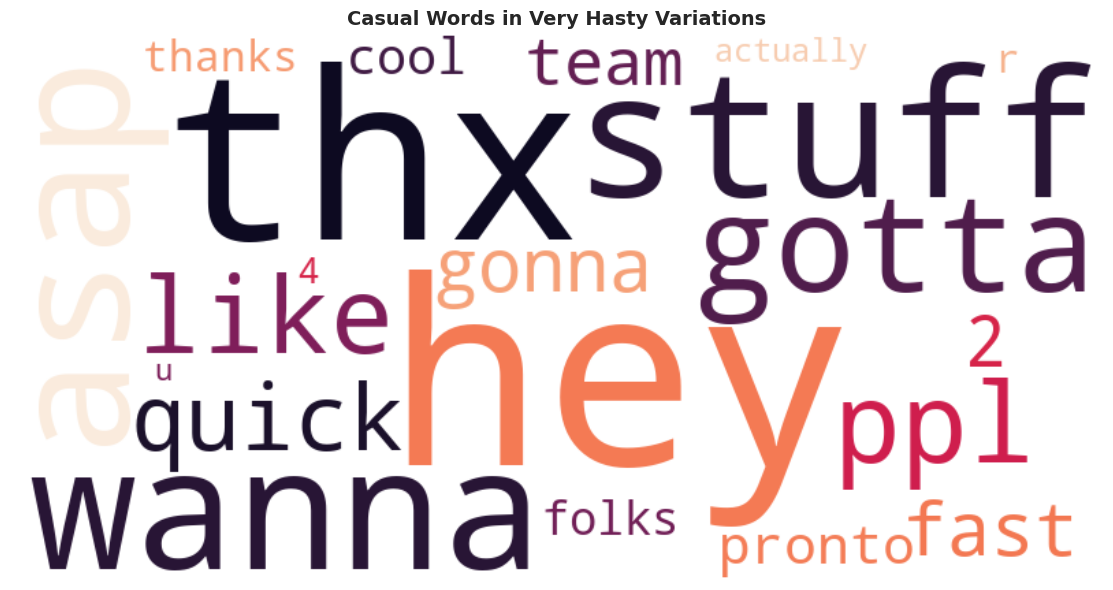

In [21]:
#making a wordcloud for the most common words in the Purpose column for very hasty variations
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filter casual words only
casual_word_freq = {word: count for word, count in all_word_counts.items() 
                    if word in casual_words and count > 5}

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='rocket',
    max_words=50
).generate_from_frequencies(casual_word_freq)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Casual Words in Very Hasty Variations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()